In [7]:
import pandas as pd
import numpy as np

In [8]:
df = pd.read_excel("/home/saheel/Documents/ITC/coursework/quartile-4/Spatio-Temporal-Analysis/Group-Assignment/AssignmentData/2006-2014 Tekenvangsten Natuurkalender voor ITC_.xlsx", sheet_name=2)
df.head()

,Collection month,Location,Plot number,Week number,Date,Day,Month,Year,Nymph
0,7,Schiermonnikoog,1,27,2006-07-08 00:00:00,8.0,7.0,2006,1.0
1,8,Schiermonnikoog,1,31,2006-08-05 00:00:00,5.0,8.0,2006,2.0
2,9,Schiermonnikoog,1,35,2006-09-02 00:00:00,2.0,9.0,2006,2.0
3,10,Schiermonnikoog,1,40,2006-10-07 00:00:00,7.0,10.0,2006,0.0
4,11,Schiermonnikoog,1,44,2006-11-04 00:00:00,4.0,11.0,2006,1.0


In [9]:
df.shape

(3072, 9)

In [11]:
df.Location.unique()

array(['Schiermonnikoog', 'Appelscha', 'Gieten', 'Nijverdal',
       'Montferland', 'Ede', 'Hoog Baarlo', 'Bilthoven', 'Dronten',
       'Texel', 'Bergen aan Zee', 'Twiske', 'De Kwade Hoek', 'Wassenaar',
       'Veldhoven', 'Eijsden', 'Vaals'], dtype=object)

In [12]:
df = df[df["Location"]=="Ede"]

In [13]:
df.shape

(202, 9)

In [14]:
df

,Collection month,Location,Plot number,Week number,Date,Day,Month,Year,Nymph
884,7,Ede,1,26,2006-06-30 00:00:00,30.0,6.0,2006,36.0
885,8,Ede,1,31,2006-08-06 00:00:00,6.0,8.0,2006,27.0
886,9,Ede,1,35,2006-09-01 00:00:00,1.0,9.0,2006,30.0
887,10,Ede,1,40,2006-10-05 00:00:00,5.0,10.0,2006,15.0
888,11,Ede,1,44,2006-11-05 00:00:00,5.0,11.0,2006,2.0
...,...,...,...,...,...,...,...,...,...
1081,8,Ede,2,32,2014-08-09 00:00:00,9.0,8.0,2014,2.0
1082,9,Ede,2,36,2014-09-07 00:00:00,7.0,9.0,2014,4.0
1083,10,Ede,2,41,2014-10-12 00:00:00,12.0,10.0,2014,3.0
1084,11,Ede,2,45,2014-11-09 00:00:00,9.0,11.0,2014,6.0


/tmp/ipykernel_119596/459579339.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["reporting_date"] = pd.to_datetime(df["Date"])
/tmp/ipykernel_119596/459579339.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['month_year'] = df['reporting_date'].dt.to_period('M')


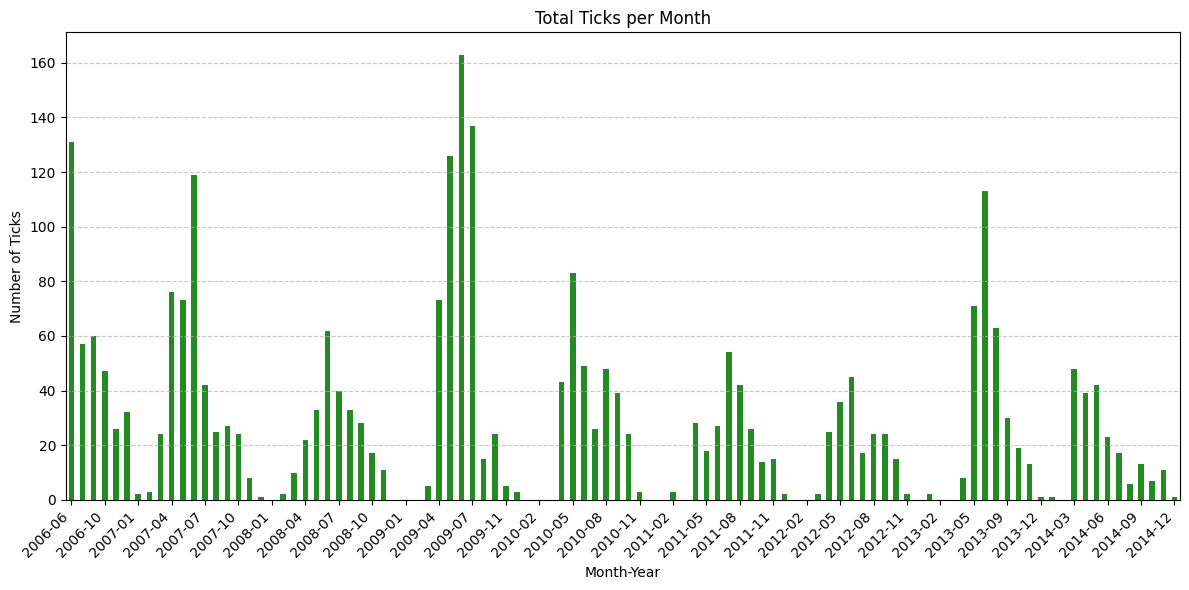

In [15]:
import matplotlib.pyplot as plt

df["reporting_date"] = pd.to_datetime(df["Date"])
df['month_year'] = df['reporting_date'].dt.to_period('M')

monthly_counts = df.groupby("month_year")["Nymph"].sum().sort_index()

plt.figure(figsize=(12, 6))
monthly_counts.plot(kind='bar', color='forestgreen')

plt.title("Total Ticks per Month")
plt.xlabel("Month-Year")
plt.ylabel("Number of Ticks")

# Reduce number of xticks
xticks = plt.gca().get_xticks()
labels = plt.gca().get_xticklabels()
plt.xticks(xticks[::3], [label.get_text() for i, label in enumerate(labels) if i % 3 == 0], rotation=45, ha='right')

plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


/tmp/ipykernel_119596/1044161700.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Month'] = df["Month"].astype("int")


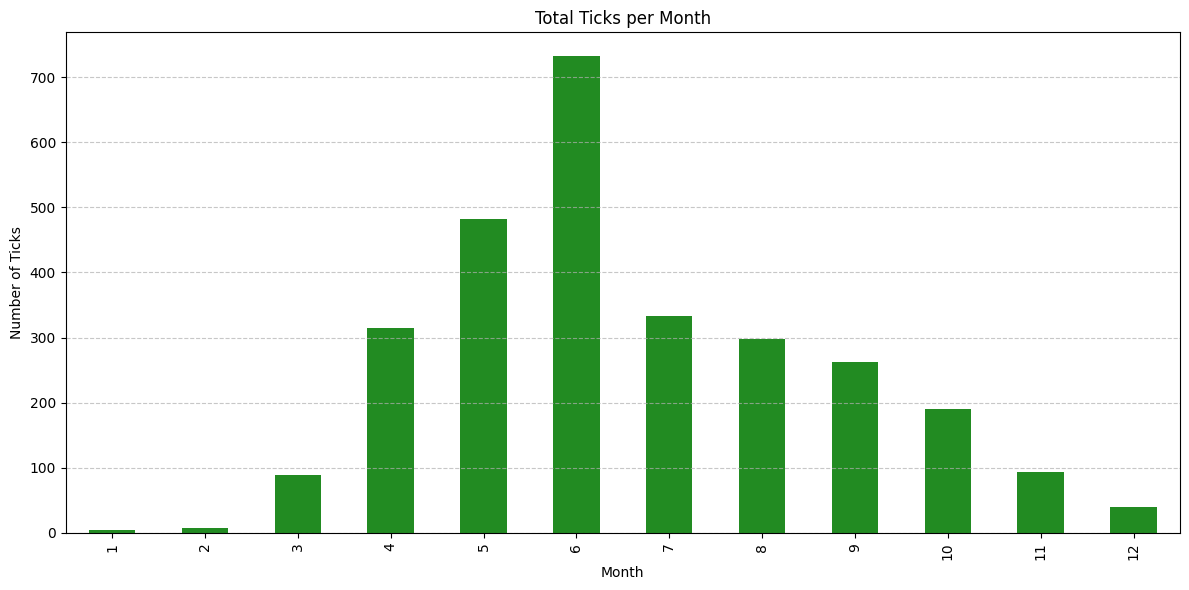

In [30]:
import matplotlib.pyplot as plt

# df["reporting_date"] = pd.to_datetime(df["Date"])
# df['month_year'] = df['reporting_date'].dt.to_period('M')

df['Month'] = df["Month"].astype("int")
monthly_counts_overall = df.groupby("Month")["Nymph"].sum().sort_index()

plt.figure(figsize=(12, 6))
monthly_counts_overall.plot(kind='bar', color='forestgreen')

plt.title("Total Ticks per Month")
plt.xlabel("Month")
plt.ylabel("Number of Ticks")

# # Reduce number of xticks
# xticks = plt.gca().get_xticks()
# labels = plt.gca().get_xticklabels()
# plt.xticks(xticks[::3], [label.get_text() for i, label in enumerate(labels) if i % 3 == 0], rotation=45, ha='right')

plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [21]:
(monthly_counts_overall / monthly_counts_overall.sum()) * 100

Month
1      0.175562
2      0.280899
3      3.125000
4     11.025281
5     16.924157
6     25.702247
7     11.692416
8     10.463483
9      9.199438
10     6.706461
11     3.300562
12     1.404494
Name: Nymph, dtype: float64

/tmp/ipykernel_119596/1177962706.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['day_name'] = pd.to_datetime(df["Date"]).dt.day_name()


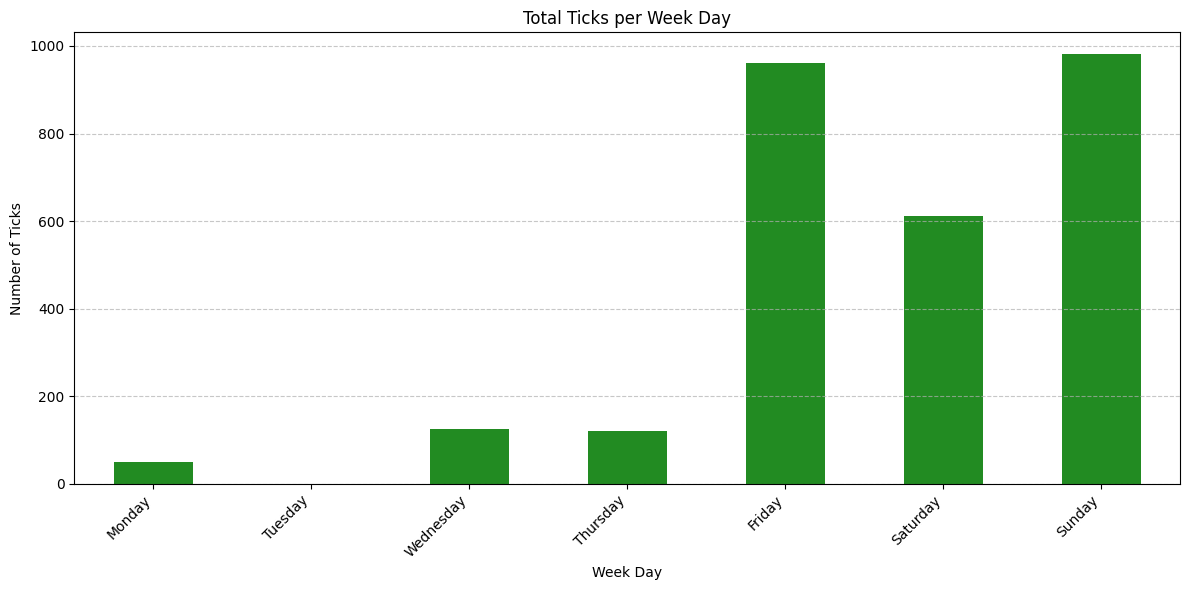

In [27]:
import matplotlib.pyplot as plt

# Convert to day names
df['day_name'] = pd.to_datetime(df["Date"]).dt.day_name()

# Define correct weekday order
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Group and reindex to ensure correct order
weekday_counts = (
    df.groupby("day_name")["Nymph"]
    .sum()
    .reindex(weekday_order)
)

# Plot
plt.figure(figsize=(12, 6))
weekday_counts.plot(kind='bar', color='forestgreen')

plt.title("Total Ticks per Week Day")
plt.xlabel("Week Day")
plt.ylabel("Number of Ticks")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


/tmp/ipykernel_119596/236030571.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['day_name'] = pd.to_datetime(df["Date"]).dt.day_name()


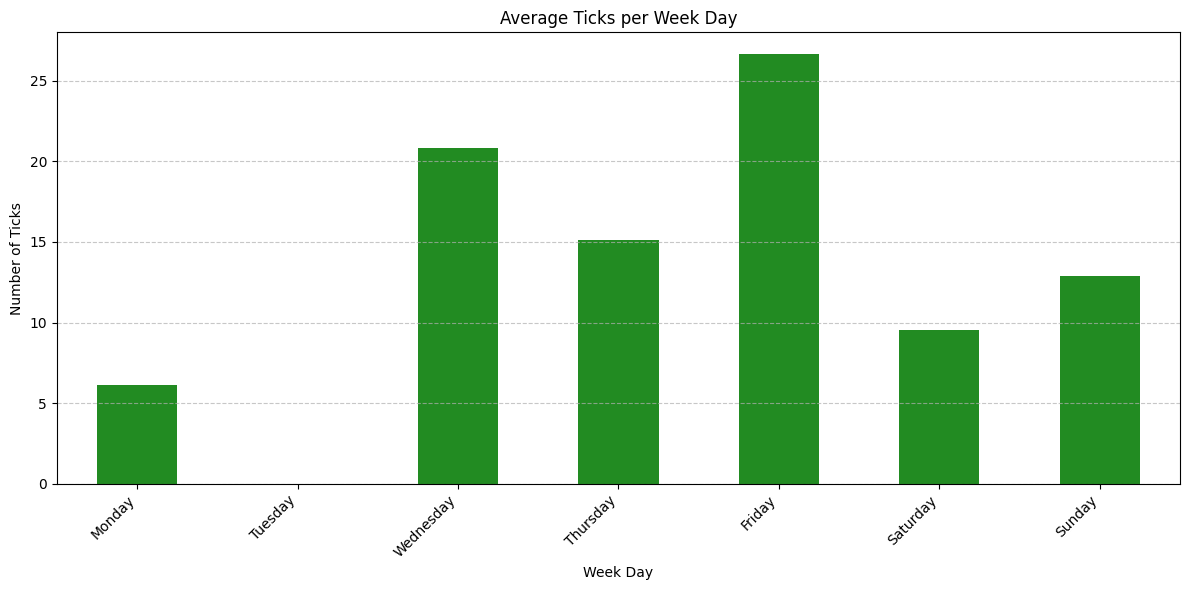

In [31]:
import matplotlib.pyplot as plt

# Convert to day names
df['day_name'] = pd.to_datetime(df["Date"]).dt.day_name()

# Define correct weekday order
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Group and reindex to ensure correct order
weekday_counts = (
    df.groupby("day_name")["Nymph"]
    .mean()
    .reindex(weekday_order)
)

# Plot
plt.figure(figsize=(12, 6))
weekday_counts.plot(kind='bar', color='forestgreen')

plt.title("Average Ticks per Week Day")
plt.xlabel("Week Day")
plt.ylabel("Number of Ticks")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [32]:
weekday_counts

day_name
Monday        6.125000
Tuesday            NaN
Wednesday    20.833333
Thursday     15.125000
Friday       26.666667
Saturday      9.546875
Sunday       12.921053
Name: Nymph, dtype: float64